# Coupling Flow with Mixture-CDF Transform

The first notebook trained a Gaussianization flow by stacking *unconditional* marginal layers (mixture CDF per dim) and rotations. The marginal layers can only Gaussianize each dimension independently; cross-dimensional structure is left entirely to the rotations.

A **coupling layer** (Real NVP, 2016) replaces that with a *conditional* transform. Given a split of the input dims:

1. Split $x = (x_a, x_b)$ with $x_a$ the identity half and $x_b$ the transformed half.
2. A *conditioner* network $\theta(x_a)$ outputs the mixture parameters $(\pi, \mu, \log\sigma)$ for each dimension in $x_b$.
3. Apply the mixture-CDF Gaussianization to $x_b$ using those *per-example* parameters: $z_b = \Phi^{-1}(F(x_b; \theta(x_a)))$.
4. Leave $z_a = x_a$ unchanged.

Since the Jacobian is lower triangular, the log-det is just the sum of per-b-dim diagonal contributions — same form as the unconditional marginal layer, but now the distribution of $z_b$ depends on $x_a$, so cross-dimensional structure is learnt directly. We pair two coupling layers with **swapped halves** inside each block so both halves get transformed (the flowjax equivalent of the Keras `[coupling(mask=m), coupling(mask=~m)]` pair is `[coupling, Flip, coupling, Flip]`).

## Mathematical structure

### Notation and shapes

Throughout: batch dimension $N$, input dimensionality $d$, mixture components $K$.

- With the default half-split for $d = 2$ we have $d_a = 1$ dim passes through, $d_b = 1$ dim gets transformed.
- $x \in \mathbb{R}^{N \times d}$ splits into $x_a \in \mathbb{R}^{N \times d_a}$ and $x_b \in \mathbb{R}^{N \times d_b}$.

### The bijector — GMM per b-dim

Each transformed dimension $i \in b$ has its own per-example mixture of $K$ Gaussians,
$$F_i(x_{b,i};\,\pi_i, \mu_i, \sigma_i) \;=\; \sum_{k=1}^{K} \pi_{i,k}\,\Phi\!\big((x_{b,i} - \mu_{i,k})/\sigma_{i,k}\big),$$
and the per-b-dim forward is exactly the mixture-CDF Gaussianization from notebook 01 — the **same** primitive, only difference is that $(\pi_i, \mu_i, \sigma_i)$ now depend on $x_a$:
$$z_{b,i} \;=\; \Phi^{-1}\!\big(F_i(x_{b,i};\,\theta_i(x_a))\big).$$
The per-example parameter tensors have shape $(N, d_b, K)$.

### The conditioner — a plain MLP

`MixtureGaussianCDFCoupling` wraps `flowjax.bijections.Coupling` with a default `nn_width × nn_depth` MLP conditioner whose final Dense is *not* zero-initialised by default. To reproduce the Keras flow's "flow starts at identity" behavior you can use `fit_rbig_coupling` (notebook 03), which installs zero-kernel final Dense weights and a data-adapted bias — equivalent to a full-data IG init.

### Log-scale clamp

Raw conditioner outputs for $\log \sigma$ are passed through a bounded map before being exponentiated,
$$\log \sigma_{i,k} \;=\; B\,\tanh(\tilde{\log\sigma}_{i,k}),$$
with default $B = 5$ so $\sigma \in [e^{-5}, e^5] \approx [0.007, 148]$. This keeps scales from blowing up or collapsing during training, especially when the conditioner is still warming up.

### Jacobian of the coupling layer

With $z_a = x_a$ and $z_b = \Phi^{-1}(F(x_b;\,\theta(x_a)))$, the Jacobian is block-triangular:
$$J \;=\; \begin{pmatrix} I_{d_a} & 0 \\ \ast & \mathrm{diag}(\partial z_{b,i} / \partial x_{b,i}) \end{pmatrix},
\qquad \log\lvert\det J\rvert \;=\; \sum_{i \in b} \log\lvert \partial z_{b,i} / \partial x_{b,i} \rvert.$$
The lower-left off-diagonal depends on $\partial \theta(x_a)/\partial x_a$ (the conditioner Jacobian) but that block doesn't enter the determinant — only the diagonal of the bottom-right matters. Same diagonal-log-det structure as the unconditional layer.

### Comparison to classical Real NVP (affine coupling)

Real NVP / Glow use an **affine** coupling,
$$z_b \;=\; x_b \odot \exp\!\big(s(x_a)\big) + t(x_a).$$
Our layer uses a **mixture-CDF** coupling — strictly more expressive per-b-dim (can handle multimodal conditional distributions), same diagonal-Jacobian structure, same cost.

### Half-swap pair per block

A single coupling layer only transforms one half. One block therefore uses *two* coupling layers with swapped halves (`[coupling, Flip, coupling, Flip]`) so **both** halves get touched. A Householder rotation at the start of each block mixes information across dims before the pair fires.

In [1]:
from __future__ import annotations

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from flowjax.bijections import Chain, Flip, Invert, Scan
from flowjax.distributions import Normal, Transformed
from flowjax.train import fit_to_data
from sklearn.datasets import make_moons

from gauss_flows import MixtureGaussianCDFCoupling
from gauss_flows._src.transforms.bijections.linear.rotation import HouseholderRotation


# --- global plot styling ------------------------------------------------------
sns.set_theme(context="poster", style="whitegrid", palette="deep", font_scale=0.85)
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "savefig.dpi": 110,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.2,
        "figure.constrained_layout.use": True,
        "figure.constrained_layout.h_pad": 0.1,
        "figure.constrained_layout.w_pad": 0.1,
        "axes.grid.which": "both",
        "grid.linewidth": 0.7,
        "grid.alpha": 0.5,
        "axes.edgecolor": "0.25",
        "axes.linewidth": 1.1,
        "axes.titleweight": "semibold",
        "axes.labelpad": 6,
    }
)


def style_axes(ax, *, aspect=None, grid=True):
    if grid:
        ax.minorticks_on()
        ax.grid(True, which="major", linewidth=0.8, alpha=0.6)
        ax.grid(True, which="minor", linewidth=0.4, alpha=0.3)
    if aspect is not None:
        ax.set_aspect(aspect)
    return ax


def style_jointgrid(g, aspect="equal"):
    style_axes(g.ax_joint, aspect=aspect)
    style_axes(g.ax_marg_x, grid=False)
    style_axes(g.ax_marg_y, grid=False)
    for spine in ("top", "right"):
        g.ax_marg_x.spines[spine].set_visible(False)
        g.ax_marg_y.spines[spine].set_visible(False)


palette = sns.color_palette("deep")

/home/azureuser/localfiles/gauss_flows/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Dataset
Same two-moons dataset as in notebook 01 so the comparison is clean.

/home/azureuser/localfiles/gauss_flows/.venv/lib/python3.13/site-packages/seaborn/axisgrid.py:1766: UserWarning: The figure layout has changed to tight
  f.tight_layout()


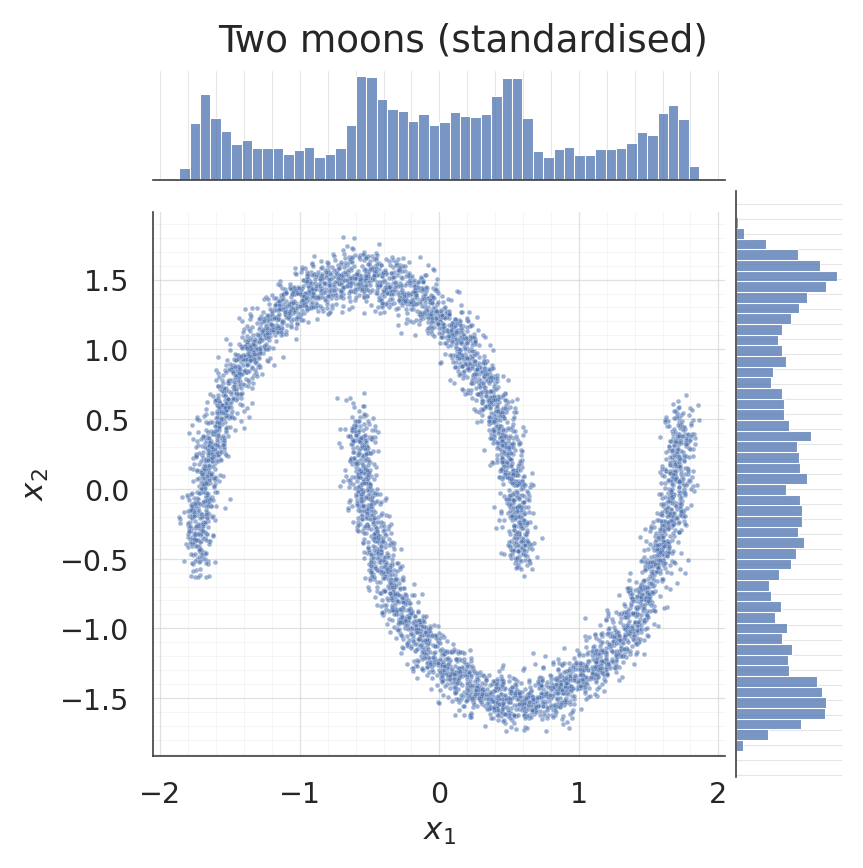

In [2]:
X_raw, _ = make_moons(n_samples=5000, noise=0.05, random_state=0)
X = (X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)
X = jnp.asarray(X, dtype=jnp.float32)

g = sns.jointplot(
    x=np.asarray(X[:, 0]),
    y=np.asarray(X[:, 1]),
    kind="scatter",
    color=palette[0],
    height=7.5,
    ratio=5,
    space=0.1,
    joint_kws={"s": 10, "alpha": 0.55},
    marginal_kws={"bins": 50, "color": palette[0], "alpha": 0.75, "edgecolor": "white"},
)
g.set_axis_labels("$x_1$", "$x_2$")
g.figure.suptitle("Two moons (standardised)", y=1.02)
style_jointgrid(g)
plt.show()

## 2. Build a coupling flow

Each block is `[HouseholderRotation, MixtureGaussianCDFCoupling, Flip, MixtureGaussianCDFCoupling, Flip]`. The two coupling layers with complementary halves (separated by `Flip`) together transform **all** dimensions; the Householder rotation mixes the already-transformed state before the next block.

With `d = 2` and the default half-split, the first coupling conditions on dim 0 and transforms dim 1, the `Flip` swaps dim order, the second coupling conditions on the ex-dim-1 (now first) and transforms the ex-dim-0 (now second), and the trailing `Flip` restores dim order so the next block's rotation sees the expected orientation.

In [3]:
key = jr.key(0)
flow_key, train_key, sample_key = jr.split(key, 3)

n_blocks = 4
n_components = 8
nn_width = 64
nn_depth = 2
n_dims = 2


def make_block(k):
    rot_key, coup1_key, coup2_key = jr.split(k, 3)
    rot = HouseholderRotation(n_reflections=n_dims, shape=(n_dims,))
    rot = eqx.tree_at(lambda r: r.params, rot, jr.normal(rot_key, rot.params.shape))
    coup1 = MixtureGaussianCDFCoupling(
        coup1_key,
        shape=(n_dims,),
        n_components=n_components,
        nn_width=nn_width,
        nn_depth=nn_depth,
    )
    coup2 = MixtureGaussianCDFCoupling(
        coup2_key,
        shape=(n_dims,),
        n_components=n_components,
        nn_width=nn_width,
        nn_depth=nn_depth,
    )
    flip = Flip(shape=(n_dims,))
    return Chain([rot, coup1, flip, coup2, flip])


blocks = eqx.filter_vmap(make_block)(jr.split(flow_key, n_blocks))
bijection = Invert(Scan(blocks))
base = Normal(jnp.zeros(n_dims))
flow = Transformed(base, bijection)

n_params = sum(
    int(np.prod(p.shape))
    for p in jax.tree_util.tree_leaves(eqx.filter(flow, eqx.is_inexact_array))
)
print(f"blocks                    : {n_blocks}")
print(f"sub-bijections per block  : 5  (rot, coupling, flip, coupling, flip)")
print(f"mixture components / dim  : {n_components}")
print(f"total inexact-array params: {n_params}")

blocks                    : 4
sub-bijections per block  : 5  (rot, coupling, flip, coupling, flip)
mixture components / dim  : 8
total inexact-array params: 46804


## 3. Train

Same training recipe as the marginal-only flow (Adam via `fit_to_data`, NLL loss, 200 epochs), so differences in the final density/pushforward are attributable to the coupling architecture.

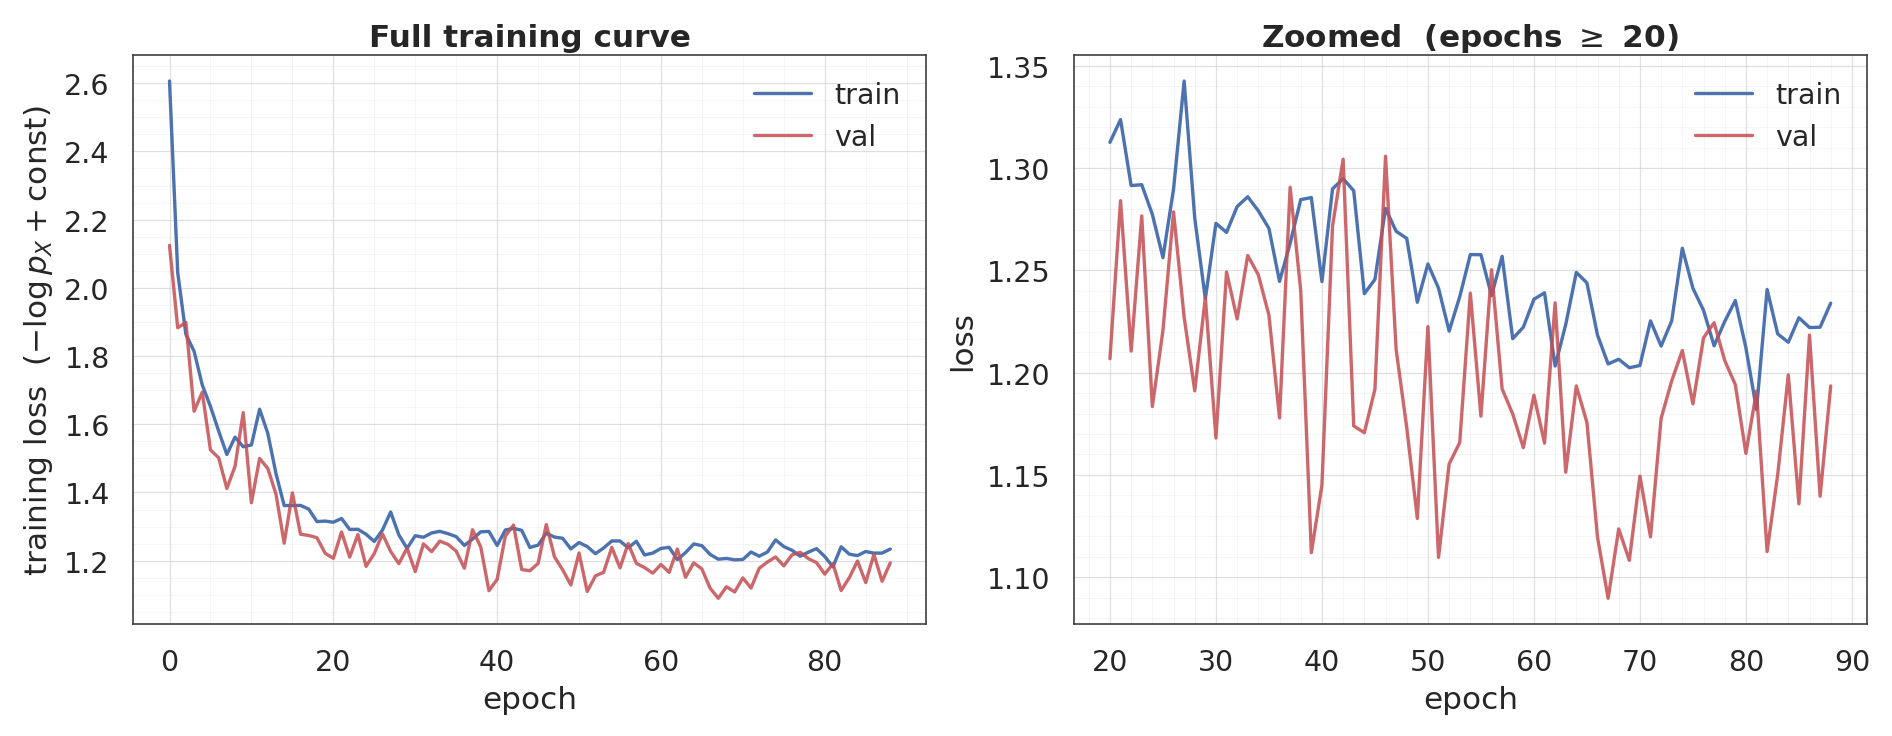

final train NLL: +1.2340   (min: +1.1819)
final   val NLL: +1.1935   (min: +1.0896)


In [4]:
trained, losses = fit_to_data(
    train_key,
    flow,
    X,
    learning_rate=2e-3,
    max_epochs=200,
    max_patience=20,
    batch_size=256,
    val_prop=0.1,
    show_progress=False,
)
train_loss = np.asarray(losses["train"])
val_loss = np.asarray(losses["val"])

fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
c = palette[0]

ax = axes[0]
ax.plot(train_loss, color=c, linewidth=2.2, label="train")
ax.plot(val_loss, color=palette[3], linewidth=2.2, alpha=0.85, label="val")
ax.set_xlabel("epoch")
ax.set_ylabel(r"training loss  $(-\log p_X + \text{const})$")
ax.set_title("Full training curve")
ax.legend(frameon=False)
style_axes(ax)

ax = axes[1]
tail_start = 20
tail_t = train_loss[tail_start:]
tail_v = val_loss[tail_start:]
ax.plot(
    range(tail_start, len(train_loss)), tail_t, color=c, linewidth=2.2, label="train"
)
ax.plot(
    range(tail_start, len(val_loss)),
    tail_v,
    color=palette[3],
    linewidth=2.2,
    alpha=0.85,
    label="val",
)
lo = min(tail_t.min(), tail_v.min())
hi = max(tail_t.max(), tail_v.max())
span = hi - lo
ax.set_ylim(lo - 0.05 * span, hi + 0.05 * span)
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title(f"Zoomed  (epochs $\\geq$ {tail_start})")
ax.legend(frameon=False)
style_axes(ax)

plt.show()
print(f"final train NLL: {train_loss[-1]:+.4f}   (min: {train_loss.min():+.4f})")
print(f"final   val NLL: {val_loss[-1]:+.4f}   (min: {val_loss.min():+.4f})")

## 4. Pushforward and density

The pushforward $z = f(x)$ should be approximately $\mathcal{N}(0, I)$. A jointplot puts the 2-D scatter next to the per-dim marginals; the black reference curves are $\varphi(z)$.

Unlike a marginal-only flow, here the conditioner can express the cross-dim dependence exactly (each $z_b$ is conditional on $x_a$) — the density contour in $x$-space should trace the two moons sharply.

pushforward diagnostics
  mean:      [-0.040, +0.001]   target = [0, 0]
  cov[0,0]:  0.839                  target = 1
  cov[1,1]:  1.124                  target = 1
  cov[0,1]:  -0.055                  target = 0


/home/azureuser/localfiles/gauss_flows/.venv/lib/python3.13/site-packages/seaborn/axisgrid.py:1766: UserWarning: The figure layout has changed to tight
  f.tight_layout()


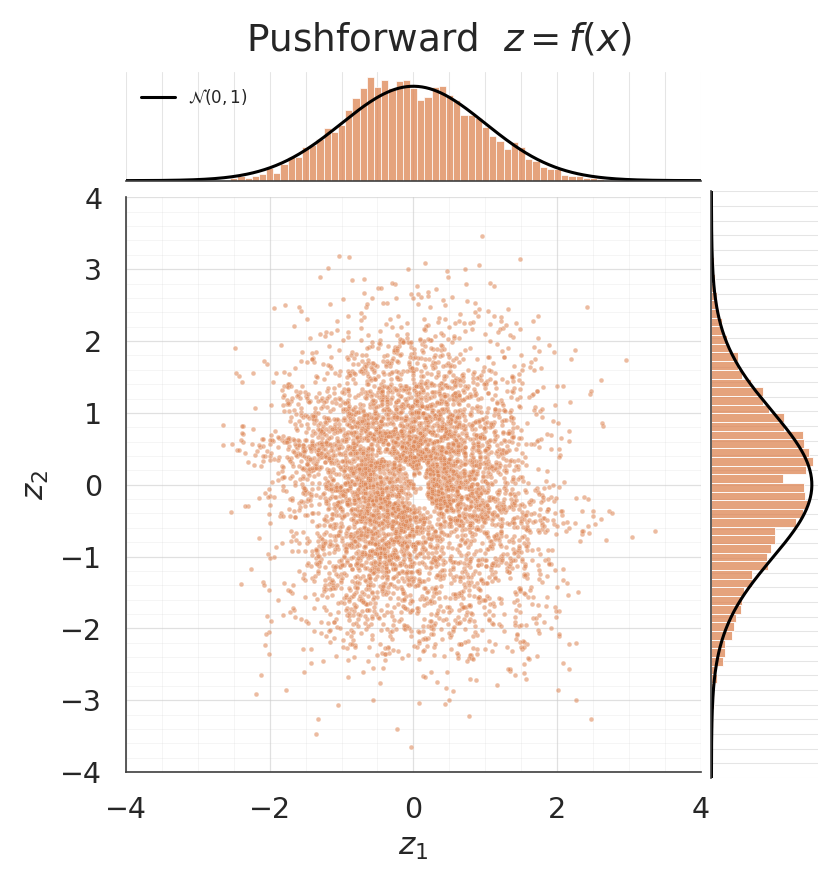

In [5]:
z = np.asarray(jax.vmap(trained.bijection.inverse)(X))
mean_z = z.mean(axis=0)
cov_z = np.cov(z, rowvar=False)
print("pushforward diagnostics")
print(f"  mean:      [{mean_z[0]:+.3f}, {mean_z[1]:+.3f}]   target = [0, 0]")
print(f"  cov[0,0]:  {cov_z[0, 0]:.3f}                  target = 1")
print(f"  cov[1,1]:  {cov_z[1, 1]:.3f}                  target = 1")
print(f"  cov[0,1]:  {cov_z[0, 1]:+.3f}                  target = 0")

g = sns.jointplot(
    x=z[:, 0],
    y=z[:, 1],
    kind="scatter",
    color=palette[1],
    height=7.5,
    ratio=5,
    space=0.1,
    joint_kws={"s": 10, "alpha": 0.55},
    marginal_kws={
        "bins": 60,
        "color": palette[1],
        "alpha": 0.75,
        "edgecolor": "white",
        "stat": "density",
    },
    xlim=(-4, 4),
    ylim=(-4, 4),
)
zz = np.linspace(-4, 4, 300)
phi = np.exp(-0.5 * zz**2) / np.sqrt(2 * np.pi)
g.ax_marg_x.plot(zz, phi, color="black", linewidth=2.0, label=r"$\mathcal{N}(0, 1)$")
g.ax_marg_y.plot(phi, zz, color="black", linewidth=2.0)
g.ax_marg_x.legend(loc="upper left", frameon=False, fontsize=11)
g.set_axis_labels("$z_1$", "$z_2$")
g.figure.suptitle(r"Pushforward  $z = f(x)$", y=1.02)
style_jointgrid(g)
plt.show()

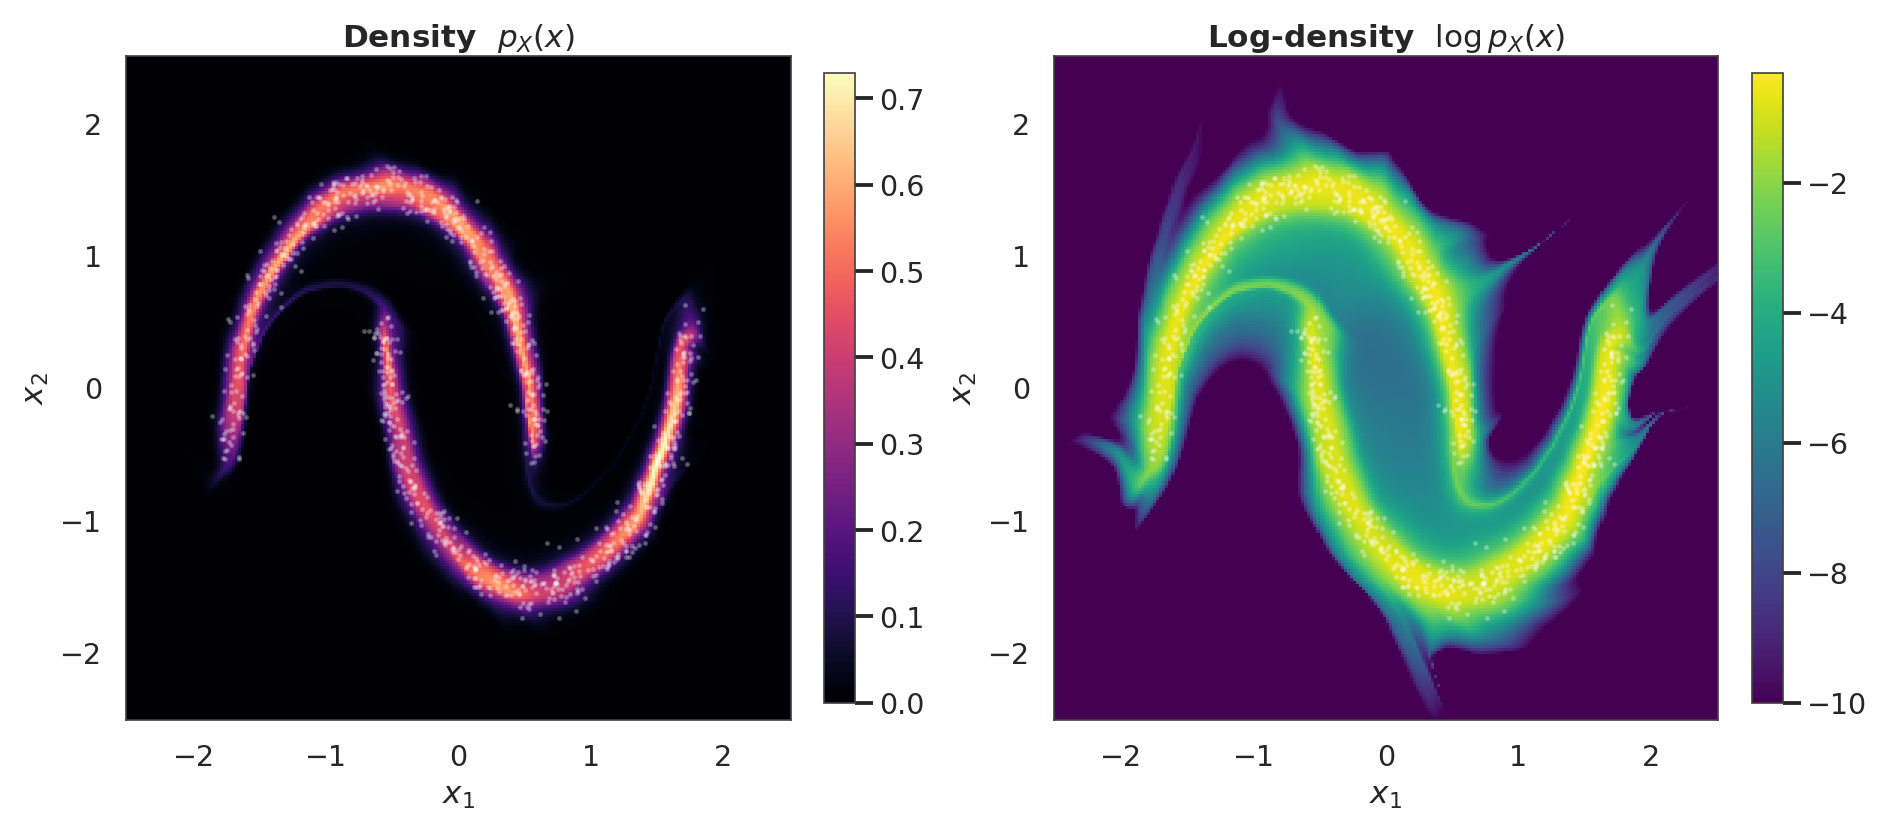

In [6]:
grid = 220
xs = np.linspace(-2.5, 2.5, grid).astype("float32")
ys = np.linspace(-2.5, 2.5, grid).astype("float32")
xx, yy = np.meshgrid(xs, ys)
pts = np.stack([xx.ravel(), yy.ravel()], axis=-1).astype("float32")

log_px = np.asarray(jax.vmap(trained.log_prob)(jnp.asarray(pts))).reshape(grid, grid)

fig, axes = plt.subplots(1, 2, figsize=(17, 7.5))

ax = axes[0]
pcm = ax.pcolormesh(xx, yy, np.exp(log_px), cmap="magma", shading="auto")
ax.scatter(
    np.asarray(X[:1000, 0]), np.asarray(X[:1000, 1]), s=2, alpha=0.25, color="white"
)
ax.set_title("Density  $p_X(x)$")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
style_axes(ax, aspect="equal")
fig.colorbar(pcm, ax=ax, shrink=0.85)

ax = axes[1]
pcm = ax.pcolormesh(xx, yy, np.clip(log_px, -10, None), cmap="viridis", shading="auto")
ax.scatter(
    np.asarray(X[:1000, 0]), np.asarray(X[:1000, 1]), s=2, alpha=0.25, color="white"
)
ax.set_title(r"Log-density  $\log p_X(x)$")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
style_axes(ax, aspect="equal")
fig.colorbar(pcm, ax=ax, shrink=0.85)
plt.show()

## 5. Sampling from the flow

$z \sim \mathcal{N}(0, I) \mapsto x = f^{-1}(z)$. Each coupling layer's inverse bisects $F(x_b; \theta(z_a)) = \Phi(z_b)$ per b-dim via `optimistix.Bisection`, with $z_a = x_a$ preserved through the layer so the conditioner sees the same input in both directions.

/home/azureuser/localfiles/gauss_flows/.venv/lib/python3.13/site-packages/seaborn/axisgrid.py:1766: UserWarning: The figure layout has changed to tight
  f.tight_layout()


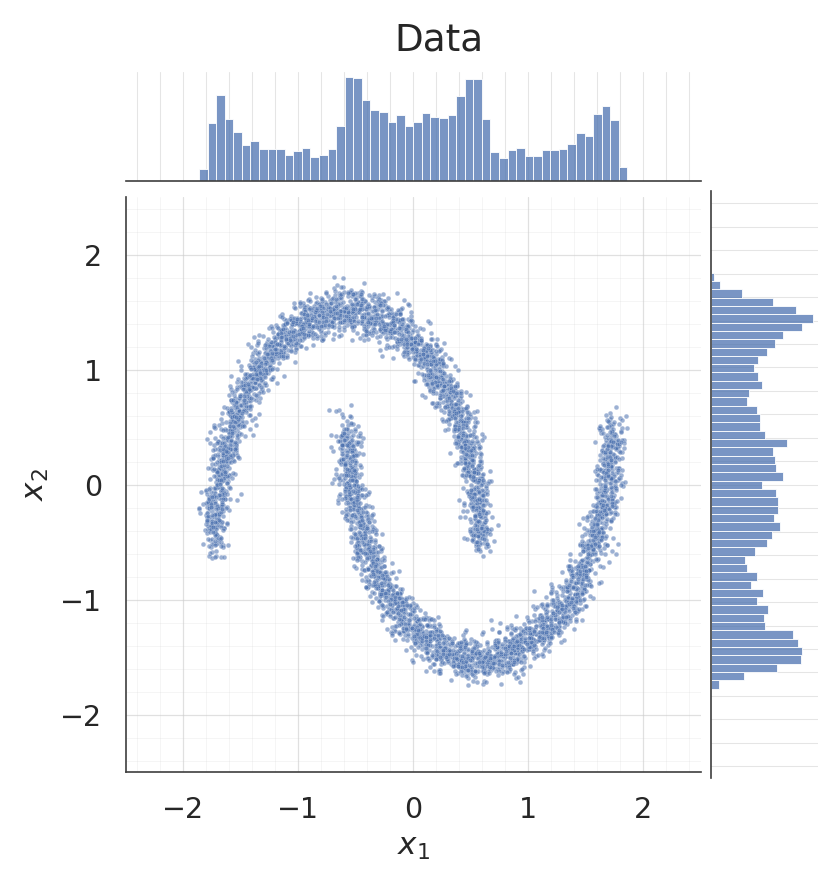

/home/azureuser/localfiles/gauss_flows/.venv/lib/python3.13/site-packages/seaborn/axisgrid.py:1766: UserWarning: The figure layout has changed to tight
  f.tight_layout()


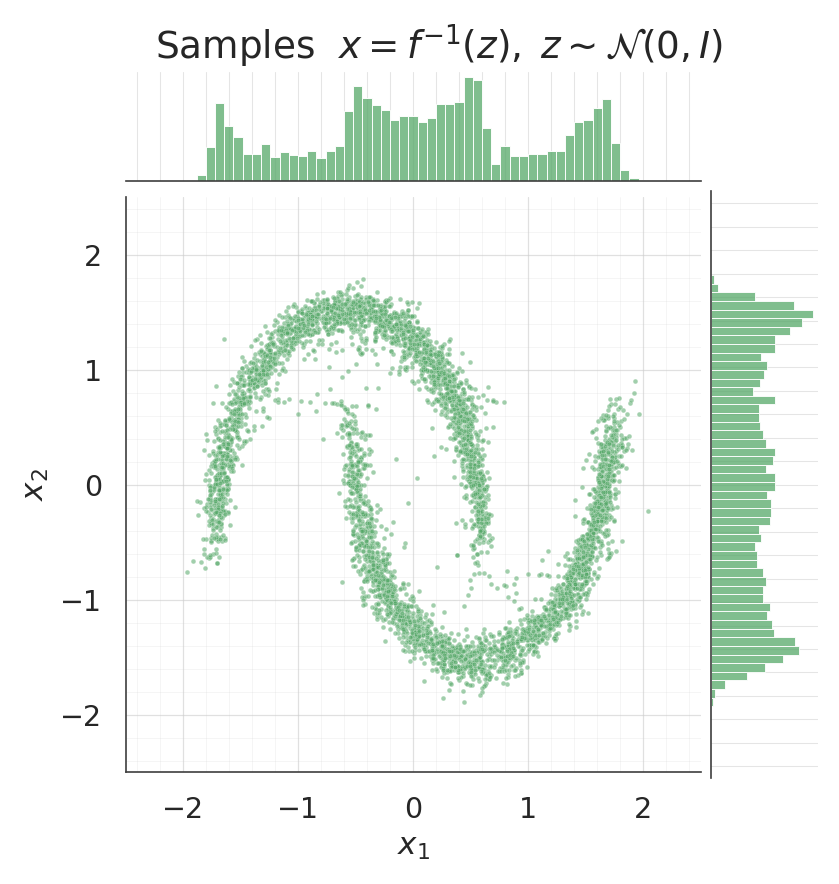

In [7]:
samples = np.asarray(trained.sample(sample_key, (5000,)))

for data, title, col in [
    (np.asarray(X), "Data", palette[0]),
    (samples, r"Samples  $x = f^{-1}(z), \; z \sim \mathcal{N}(0, I)$", palette[2]),
]:
    g = sns.jointplot(
        x=data[:, 0],
        y=data[:, 1],
        kind="scatter",
        color=col,
        height=7.5,
        ratio=5,
        space=0.1,
        joint_kws={"s": 10, "alpha": 0.55},
        marginal_kws={
            "bins": 50,
            "color": col,
            "alpha": 0.75,
            "edgecolor": "white",
        },
        xlim=(-2.5, 2.5),
        ylim=(-2.5, 2.5),
    )
    g.set_axis_labels("$x_1$", "$x_2$")
    g.figure.suptitle(title, y=1.02)
    style_jointgrid(g)
    plt.show()

## 6. Round-trip inversion

Each coupling layer is a bijection by construction, so $f^{-1}(f(x))$ should recover $x$ to numerical precision. The inverse uses `optimistix.Bisection` on the mixture CDF; small tails from the $\varepsilon$-clamp on $F(x) \in [\varepsilon, 1 - \varepsilon]$ are the only residual error.

round-trip L2 error  ||f^{-1}(f(x)) - x||_2
  median : 1.55e-06
  95th%  : 5.14e-06
  max    : 2.48e-05


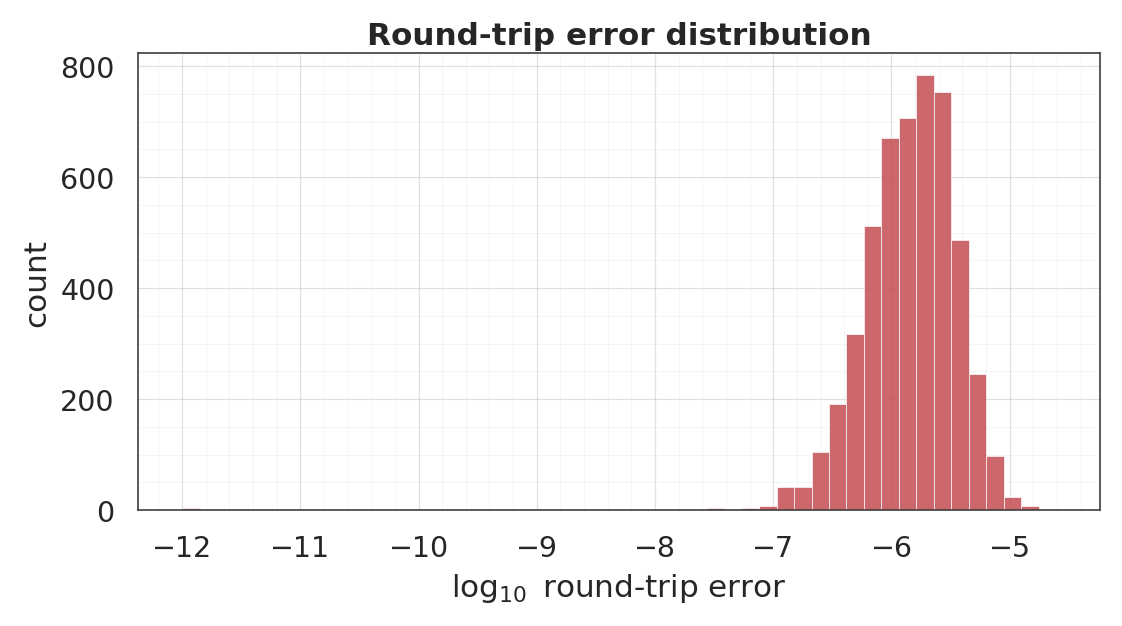

In [8]:
z_fwd = jax.vmap(trained.bijection.inverse)(X)
x_rt = jax.vmap(trained.bijection.transform)(z_fwd)
err = np.asarray(jnp.linalg.norm(x_rt - X, axis=-1))

print(r"round-trip L2 error  ||f^{-1}(f(x)) - x||_2")
print(f"  median : {np.median(err):.2e}")
print(f"  95th%  : {np.percentile(err, 95):.2e}")
print(f"  max    : {err.max():.2e}")

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.hist(
    np.log10(err + 1e-12),
    bins=50,
    color=palette[3],
    alpha=0.85,
    edgecolor="white",
    linewidth=0.5,
)
ax.set_xlabel(r"$\log_{10}$ round-trip error")
ax.set_ylabel("count")
ax.set_title("Round-trip error distribution")
style_axes(ax)
plt.show()

## 7. Layer-by-layer view

States $x,\, f_1(x),\, \ldots,\, z$. Each coupling layer transforms one half while keeping the other intact (you can see the passthrough half pinned, the other half morphing). Rotations remix the state between coupling pairs, and the flips swap which half is transformed inside a block.

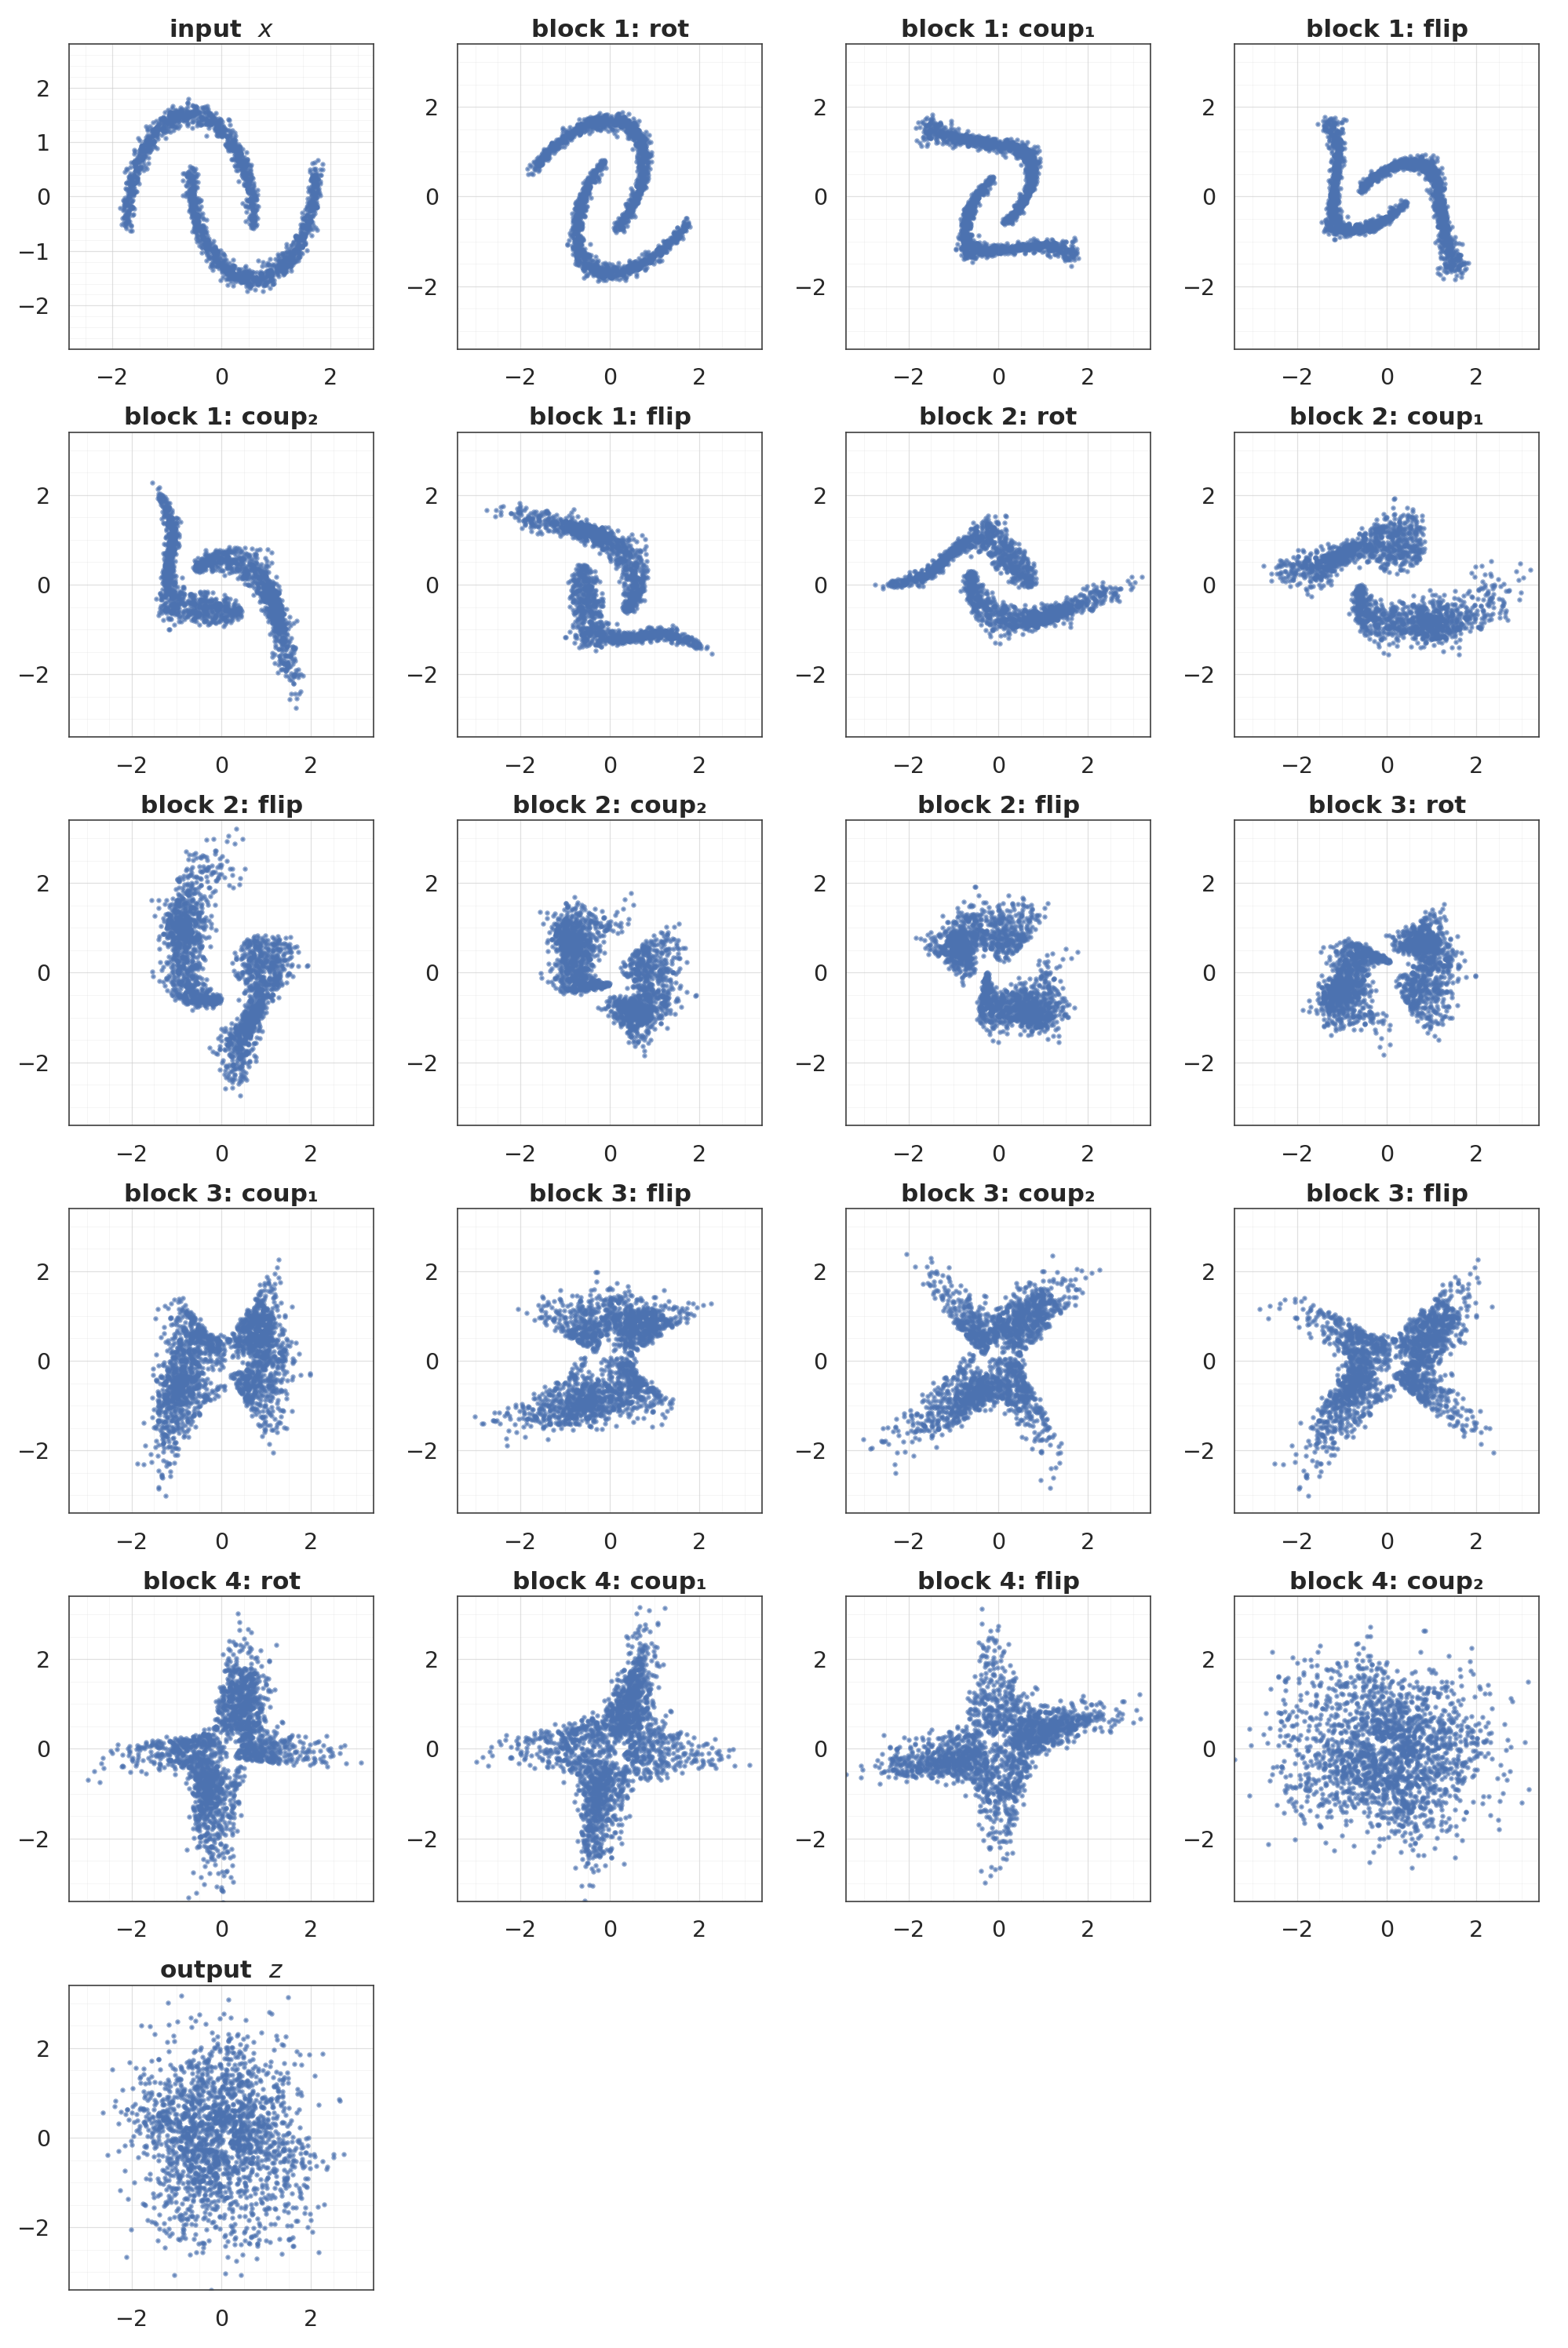

In [9]:
# Each "block" is Chain([rot, coup1, flip, coup2, flip]) with vmapped leaves.
scan_chain = trained.bijection.bijection.bijection  # Invert → Scan → Chain
X_small = X[:2000]
states = [np.asarray(X_small)]
state = X_small
# Chain.bijections is a tuple of the 5 sub-bijections, each with vmapped leaves.
sub_names = ["rot", "coup₁", "flip", "coup₂", "flip"]
titles = []
for block_idx in range(n_blocks):
    for sub_idx, name in enumerate(sub_names):
        sub = jax.tree_util.tree_map(
            lambda p, _b=block_idx: (
                p[_b]
                if isinstance(p, jax.Array) and p.ndim > 0 and p.shape[0] == n_blocks
                else p
            ),
            scan_chain.bijections[sub_idx],
        )
        state = jax.vmap(lambda s: sub.transform_and_log_det(s)[0])(state)
        states.append(np.asarray(state))
        titles.append(f"block {block_idx + 1}: {name}")

n_states = len(states)
ncol = 4
nrow = int(np.ceil(n_states / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.5 * ncol, 4.5 * nrow))
axes = axes.ravel()
for i, (s, ax) in enumerate(zip(states, axes)):
    ax.scatter(s[:, 0], s[:, 1], s=5, alpha=0.6, color=palette[0])
    lim = 3.4 if i > 0 else 2.8
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    if i == 0:
        ax.set_title("input  $x$")
    elif i == n_states - 1:
        ax.set_title("output  $z$")
    else:
        ax.set_title(titles[i - 1])
    style_axes(ax, aspect="equal")
for ax in axes[n_states:]:
    ax.axis("off")
plt.show()

## Recap

- Coupling = one half conditions, the other is transformed. Half-swap via `Flip` inside the same block so both halves get touched.
- The same mixture-CDF primitive drives both the unconditional marginal layer (notebook 01) and this layer — only difference is that the params now come from a network output instead of a learned per-dim lookup.
- Zero-kernel initialisation (via `fit_rbig_coupling` in notebook 03) makes training warm-start from a data-adapted RBIG state instead of random.
- The flowjax coupling's conditioner is a standard MLP; for 2D data with only one b-dim per coupling the "per-dim" vs "shared-mixture" distinction collapses, and there's no reason to use anything other than the default MLP. See the research_notebook for higher-dim experiments where this matters.